<a href="https://colab.research.google.com/github/Sansebastian318/Mecanica/blob/main/primera_idea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


RMSE:               0.0212
Accuracy direccional: 64.57%

Escenario pesimista  (p10): $64,617
Escenario base       (p50): $99,573
Escenario optimista  (p90): $166,048


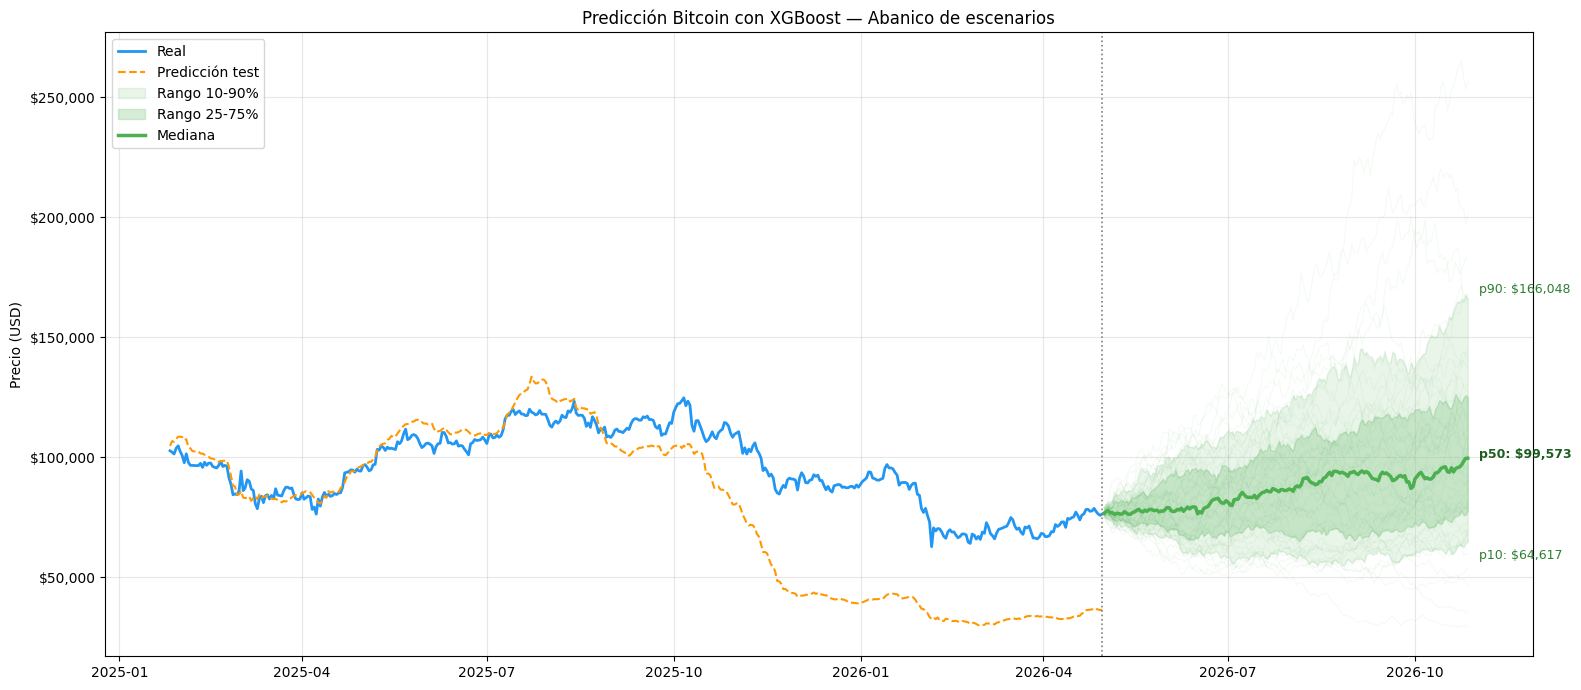

In [46]:
# 1. LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error, accuracy_score
from xgboost import XGBRegressor

# 2. DESCARGAR DATOS
btc = yf.download("BTC-USD", start="2020-01-01", end="2026-05-01", auto_adjust=True)
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

data = btc[['Close', 'Volume']].copy()

# 3. FEATURES
data['Return'] = data['Close'].pct_change()

N_LAGS      = 15
ROLLING_WIN = 15

for lag in range(1, N_LAGS + 1):
    data[f'lag_{lag}'] = data['Return'].shift(lag)

data['rolling_mean'] = data['Return'].rolling(ROLLING_WIN).mean()
data['rolling_std']  = data['Return'].rolling(ROLLING_WIN).std()
data['volume_mean']  = data['Volume'].rolling(ROLLING_WIN).mean()
data['volume_std']   = data['Volume'].rolling(ROLLING_WIN).std()

data.dropna(inplace=True)

# 4. X e y
X = data.drop(['Close', 'Return'], axis=1)
y = data['Return']

# 5. DIVIDIR
train_size  = int(len(data) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 6. MODELO
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 7. MÉTRICAS
pred_returns = model.predict(X_test)

rmse     = np.sqrt(mean_squared_error(y_test, pred_returns))
accuracy = accuracy_score((y_test > 0).astype(int), (pred_returns > 0).astype(int))
print(f"RMSE:               {rmse:.4f}")
print(f"Accuracy direccional: {accuracy:.2%}")

# 8. RECONSTRUIR PRECIOS TEST
test_prices_real = data['Close'].iloc[train_size:]
pred_prices = []
last_price  = float(data['Close'].iloc[train_size - 1])
for r in pred_returns:
    last_price = last_price * (1 + r)
    pred_prices.append(last_price)

# 9. FUNCIÓN DE FEATURES
def build_features(return_series, volume_series):
    lags = [return_series.iloc[-i] for i in range(1, N_LAGS + 1)]
    return pd.DataFrame([[
        *lags,
        volume_series.iloc[-1],
        return_series.iloc[-ROLLING_WIN:].mean(),
        return_series.iloc[-ROLLING_WIN:].std(),
        volume_series.iloc[-ROLLING_WIN:].mean(),
        volume_series.iloc[-ROLLING_WIN:].std()
    ]], columns=X.columns)

# 10. ABANICO DE PREDICCIONES FUTURAS (50 simulaciones)
future_days    = 180
N_SIMS         = 50
vol_reciente   = data['Return'].iloc[-60:].std()
all_sims       = []

for sim in range(N_SIMS):
    np.random.seed(sim)
    hist_ret   = data['Return'].copy()
    hist_vol   = data['Volume'].copy()
    sim_prices = []
    precio     = float(data['Close'].iloc[-1])

    for _ in range(future_days):
        X_fut  = build_features(hist_ret, hist_vol)
        ret    = float(model.predict(X_fut)[0])
        ret   += np.random.normal(0, vol_reciente * 0.85)
        ret    = np.clip(ret, -0.08, 0.08)
        precio = precio * (1 + ret)
        sim_prices.append(precio)

        next_date = hist_ret.index[-1] + pd.Timedelta(days=1)
        hist_ret.loc[next_date] = ret
        hist_vol.loc[next_date] = hist_vol.iloc[-20:].mean()

    all_sims.append(sim_prices)

all_sims = np.array(all_sims)
p10, p25  = np.percentile(all_sims, 10, axis=0), np.percentile(all_sims, 25, axis=0)
p75, p90  = np.percentile(all_sims, 75, axis=0), np.percentile(all_sims, 90, axis=0)
mediana   = np.median(all_sims, axis=0)

print(f"\nEscenario pesimista  (p10): ${p10[-1]:,.0f}")
print(f"Escenario base       (p50): ${mediana[-1]:,.0f}")
print(f"Escenario optimista  (p90): ${p90[-1]:,.0f}")

# 11. GRÁFICO
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days, freq='D'
)

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(test_prices_real.index, test_prices_real.values,
        color='#2196F3', linewidth=2, label='Real')
ax.plot(test_prices_real.index, pred_prices,
        color='#FF9800', linewidth=1.5, linestyle='--', label='Predicción test')

for sim_prices in all_sims:
    ax.plot(future_dates, sim_prices, color='#4CAF50', alpha=0.06, linewidth=0.8)

ax.fill_between(future_dates, p10, p90, color='#4CAF50', alpha=0.12, label='Rango 10-90%')
ax.fill_between(future_dates, p25, p75, color='#4CAF50', alpha=0.22, label='Rango 25-75%')
ax.plot(future_dates, mediana, color='#4CAF50', linewidth=2.5, label='Mediana')

ax.axvline(x=data.index[-1], color='gray', linestyle=':', linewidth=1.2)

ax.annotate(f'p90: ${p90[-1]:,.0f}',  xy=(future_dates[-1], p90[-1]),  xytext=(8,  4), textcoords='offset points', fontsize=9, color='#2E7D32')
ax.annotate(f'p50: ${mediana[-1]:,.0f}', xy=(future_dates[-1], mediana[-1]), xytext=(8,  0), textcoords='offset points', fontsize=9, color='#1B5E20', fontweight='bold')
ax.annotate(f'p10: ${p10[-1]:,.0f}',  xy=(future_dates[-1], p10[-1]),  xytext=(8, -12), textcoords='offset points', fontsize=9, color='#2E7D32')

ax.legend(loc='upper left')
ax.set_title('Predicción Bitcoin con XGBoost — Abanico de escenarios')
ax.set_ylabel('Precio (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()